In [2]:
#type: ignore
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from typing import List, Literal
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

In [3]:
df = pd.read_csv('data.csv')
df.head()

,review,target
0,sản_phẩm đẹp hình,1
1,giao hàng rất nhanh cần gấp nấu mở thất_vọng v...,0
2,chảo vênh lòng cao giữa trũng xung_quanh rán k...,0
3,hàng tốt,1
4,bình tốt giá_cả hợp_lý màu tím thiên màu tím t...,1


In [4]:
df['target'].value_counts().to_frame()

,count
target,
1,49719
0,10960


<Axes: xlabel='target', ylabel='count'>

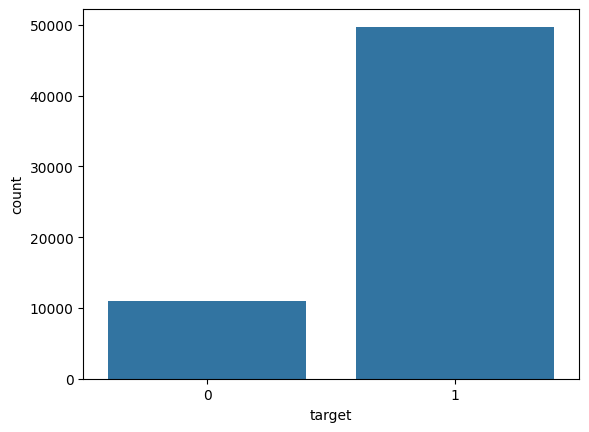

In [5]:
sns.countplot(data=df, x='target')

In [6]:
x_full, y_full = df['review'], df['target']
SEED = 42

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x_full, y_full, test_size=0.2, stratify=y_full, random_state=SEED)

In [8]:
x_train.shape

(48543,)

In [9]:
x_test.shape

(12136,)

In [10]:
y_train.shape

(48543,)

In [11]:
y_test

2189     1
56624    1
25220    1
7214     1
3658     1
        ..
6003     1
4793     1
18177    1
49838    1
47996    1
Name: target, Length: 12136, dtype: int64

In [12]:
bow_vectorizer = CountVectorizer()
x_train_bow = bow_vectorizer.fit_transform(x_train)
x_test_bow = bow_vectorizer.transform(x_test)

tfidf_vectorizer = TfidfVectorizer()
x_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
x_test_tfidf = tfidf_vectorizer.transform(x_test)

In [13]:
def train_and_test_knn(x_train, y_train, x_test, y_test, n_neighbors:int = 5):
    knn = KNeighborsClassifier()
    knn.fit(x_train, y_train)

    y_pred = knn.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred, output_dict=True)

    return y_pred, accuracy, report

In [14]:
knn_bow_labels, knn_bow_accuracy, knn_bow_report = train_and_test_knn(x_train_bow, y_train, x_test_bow, y_test)
knn_tfidf_labels, knn_tfidf_accuracy, knn_tfidf_report = train_and_test_knn(x_train_tfidf, y_train, x_test_tfidf,
                                                                            y_test)

print("Accuracy for knn:")
print(f"Bag of Words: {knn_bow_accuracy:.4f}")
print(f"TF-IDF: {knn_tfidf_accuracy:.4f}")

Accuracy for knn:
Bag of Words: 0.8509
TF-IDF: 0.8280


In [15]:
def plot_confusion_matrix(y_true, y_pred, figure_name='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(figure_name)
    plt.show()

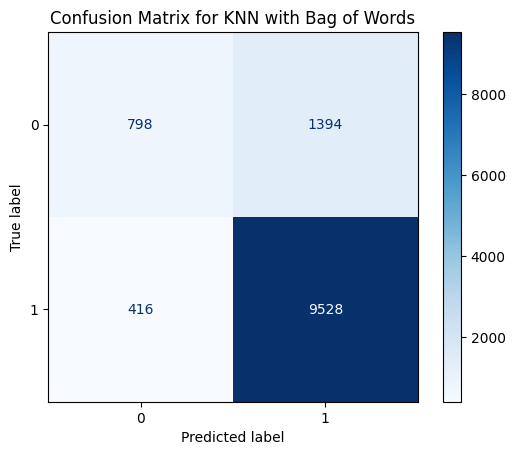

In [16]:
plot_confusion_matrix(y_test, knn_bow_labels, figure_name='Confusion Matrix for KNN with Bag of Words')

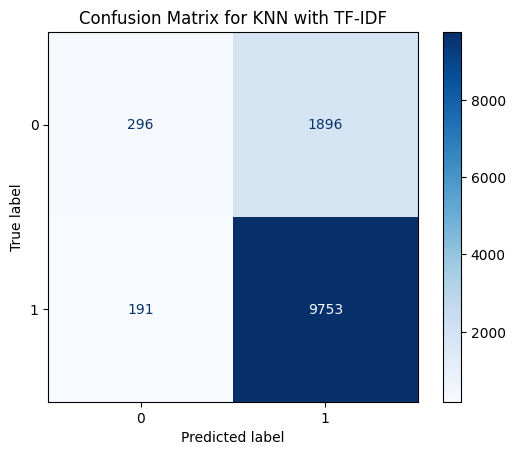

In [17]:
plot_confusion_matrix(y_test, knn_tfidf_labels, figure_name='Confusion Matrix for KNN with TF-IDF')

In [18]:
def train_and_test_decision_tree(x_train, y_train, x_test, y_test):
    dt = DecisionTreeClassifier(random_state=SEED, class_weight='balanced')
    dt.fit(x_train, y_train)

    y_pred = dt.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred, output_dict=True)

    return y_pred, accuracy, report

In [19]:
dt_bow_labels, dt_bow_accuracy, dt_bow_report = train_and_test_decision_tree(x_train_bow, y_train, x_test_bow, y_test)
dt_tfidf_labels, dt_tfidf_accuracy, dt_tfidf_report = train_and_test_decision_tree(x_train_tfidf, y_train, x_test_tfidf,
                                                                            y_test)

print("Accuracy for Decision Tree:")
print(f"Bag of Words: {dt_bow_accuracy:.4f}")
print(f"TF-IDF: {dt_tfidf_accuracy:.4f}") 

Accuracy for Decision Tree:
Bag of Words: 0.8221
TF-IDF: 0.8392


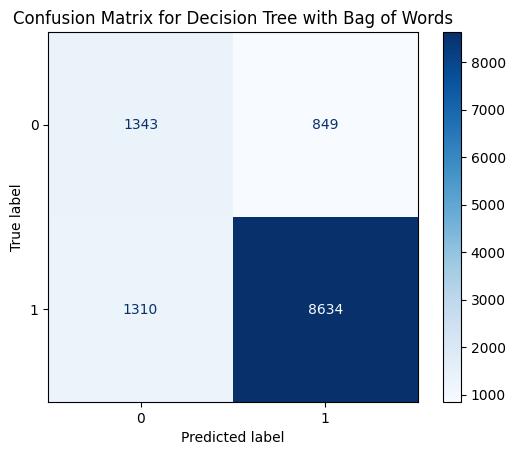

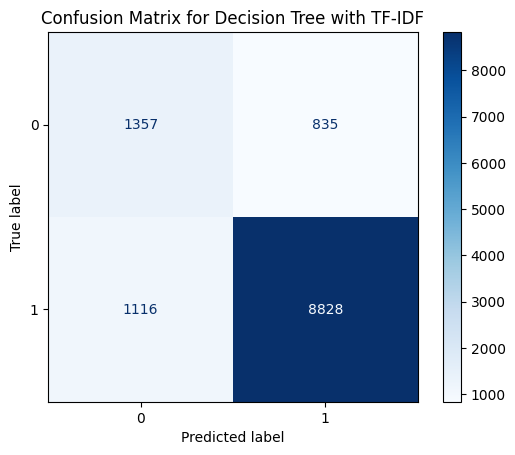

In [20]:
plot_confusion_matrix(y_test, dt_bow_labels, figure_name='Confusion Matrix for Decision Tree with Bag of Words')
plot_confusion_matrix(y_test, dt_tfidf_labels, figure_name='Confusion Matrix for Decision Tree with TF-IDF')

In [21]:
def train_and_test_naive_bayes(x_train, y_train, x_test, y_test):
    nb = MultinomialNB()
    nb.fit(x_train, y_train)
    y_pred = nb.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    return y_pred, accuracy, report

In [22]:
nb_bow_labels, nb_bow_accuracy, nb_bow_report = train_and_test_naive_bayes(x_train_bow, y_train, x_test_bow, y_test)
nb_tfidf_labels, nb_tfidf_accuracy, nb_tfidf_report = train_and_test_naive_bayes(x_train_tfidf, y_train, x_test_tfidf, y_test)

print("Accuracy for Naive Bayes:")
print(f"Bag of Words: {nb_bow_accuracy:.4f}")
print(f"TF-IDF: {nb_tfidf_accuracy:.4f}")

Accuracy for Naive Bayes:
Bag of Words: 0.8807
TF-IDF: 0.8504


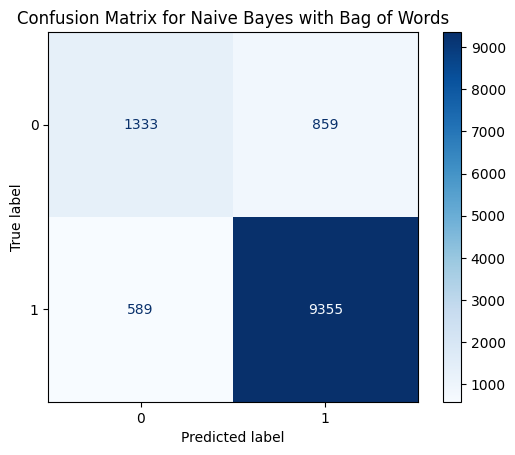

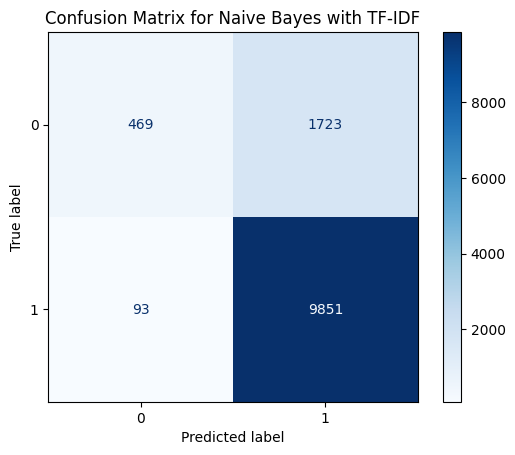

In [23]:
plot_confusion_matrix(y_test, nb_bow_labels, figure_name='Confusion Matrix for Naive Bayes with Bag of Words')
plot_confusion_matrix(y_test, nb_tfidf_labels, figure_name='Confusion Matrix for Naive Bayes with TF-IDF')

In [24]:
def train_and_test_random_forest(x_train, y_train, x_test, y_test, n_estimators: int = 100):
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=SEED, class_weight='balanced')
    rf.fit(x_train, y_train)

    y_pred = rf.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred, output_dict=True)

    return y_pred, accuracy, report

In [25]:
rf_bow_labels, rf_bow_accuracy, rf_bow_report = train_and_test_random_forest(x_train_bow, y_train, x_test_bow, y_test)
rf_tfidf_labels, rf_tfidf_accuracy, rf_tfidf_report = train_and_test_random_forest(x_train_tfidf, y_train, x_test_tfidf,
                                                                            y_test)

print("Accuracy for Random Forest:")
print(f"Bag of Words: {rf_bow_accuracy:.4f}")
print(f"TF-IDF: {rf_tfidf_accuracy:.4f}")

KeyboardInterrupt: 

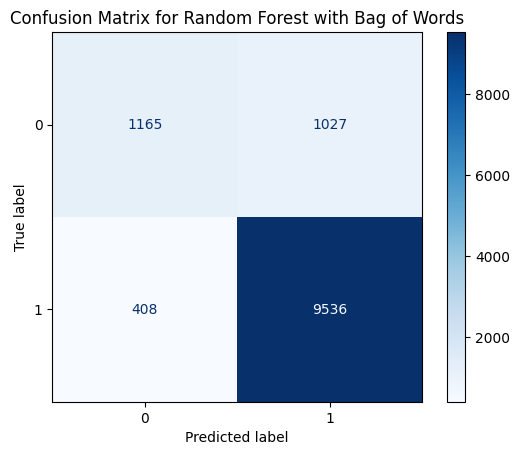

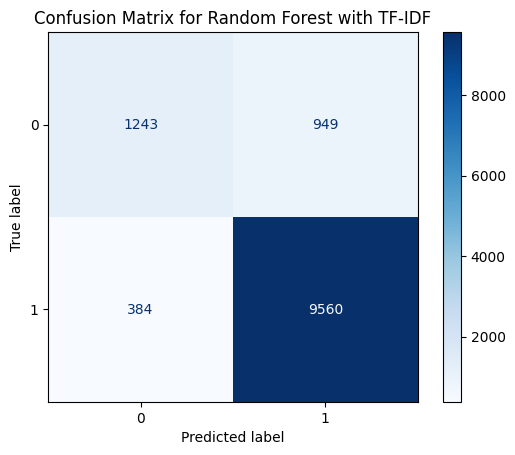

In [ ]:
plot_confusion_matrix(y_test, rf_bow_labels, figure_name='Confusion Matrix for Random Forest with Bag of Words')
plot_confusion_matrix(y_test, rf_tfidf_labels, figure_name='Confusion Matrix for Random Forest with TF-IDF')

In [ ]:
def train_and_test_svm(x_train, y_train, x_test, y_test, kernel: Literal['linear', 'rbf', 'poly'] = 'linear'):
    svm = SVC(kernel=kernel, random_state=SEED, class_weight='balanced')
    svm.fit(x_train, y_train)

    y_pred = svm.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred, output_dict=True)

    return y_pred, accuracy, report

In [ ]:
svm_bow_labels, svm_bow_accuracy, svm_bow_report = train_and_test_svm(x_train_bow, y_train, x_test_bow, y_test)
svm_tfidf_labels, svm_tfidf_accuracy, svm_tfidf_report = train_and_test_svm(x_train_tfidf, y_train, x_test_tfidf, y_test)

print("Accuracy for SVM:")
print(f"Bag of Words: {svm_bow_accuracy:.4f}")
print(f"TF-IDF: {svm_tfidf_accuracy:.4f}")

NameError: name 'train_and_test_svm' is not defined